In [39]:
# some imports

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)
 
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# create output folder
if not os.path.exists('output'):
    os.makedirs('output')
if not os.path.exists('output/session1'):
    os.makedirs('output/session1')

In [41]:

train_set = pd.read_csv('/kaggle/input/ml-ub-2025-project-1/train_set.csv',index_col=0) 
test_set = pd.read_csv('/kaggle/input/ml-ub-2025-project-1/test_set.csv',index_col=0) 


# Exploración de datos

En esta sección veremos la distribución de cada variable, cuantos valores únicos tienen y sus correlaciones. 

===== INFORMACIÓN GENERAL =====
Número de columnas: 21
Número de filas: 5432

=== Columnas de tipo object (strings/objetos) ===


Columna: Suburb
Suburb
Reservoir         143
Bentleigh East    104
Preston            96
Richmond           96
Brunswick          94
                 ... 
Burnside            1
Wallan              1
Riddells Creek      1
Diggers Rest        1
Hurstbridge         1
Name: count, Length: 292, dtype: int64
--> Categorías con frecuencia <20: 201
--> Categorías con frecuencia <10: 152
------------------------------------------------------------

Columna: Address
Address
5 Charles St            3
16/341 Heidelberg Rd    2
4 Bell St               2
14 Lennox St            2
5 Aroona Ct             2
                       ..
30 College Pde          1
33 View St              1
17 Barnard Ct           1
17 Kooyong Rd           1
31 Napoleon St          1
Name: count, Length: 5400, dtype: int64
--> Categorías con frecuencia <20: 5400
--> Categorías con frecuencia <10: 

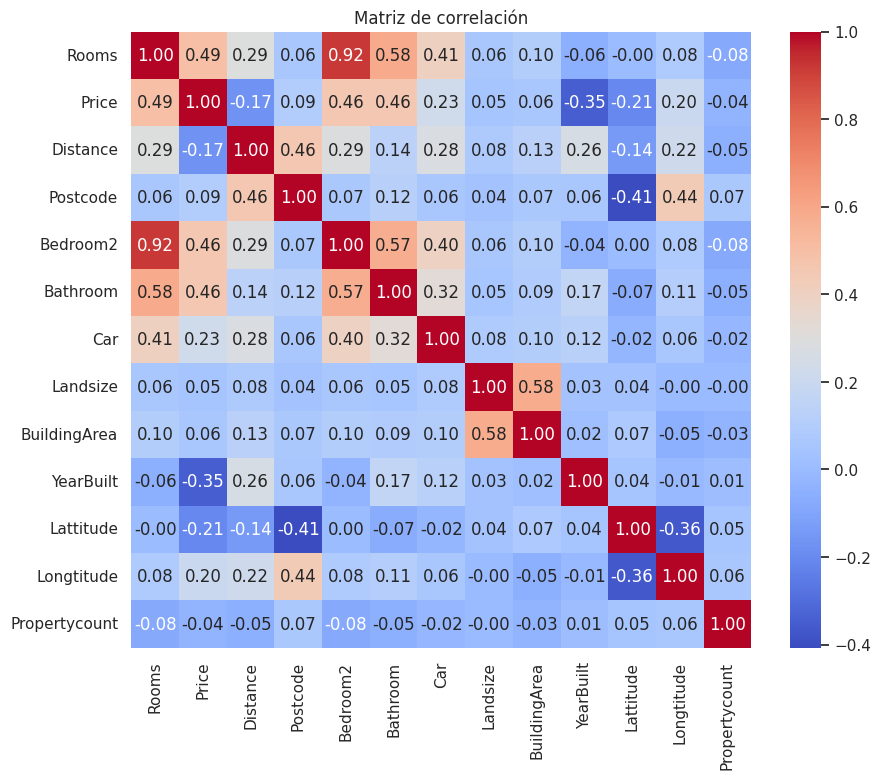


=== Histogramas de columnas numéricas ===


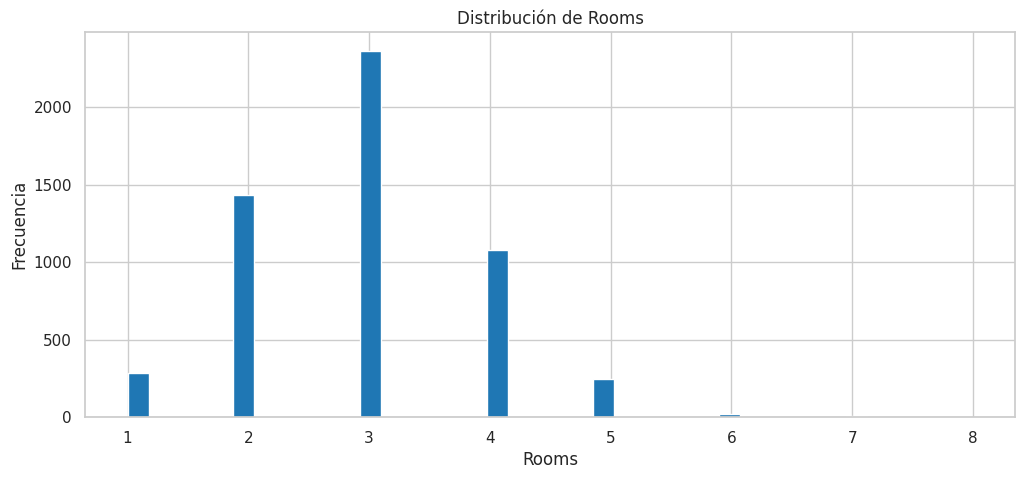

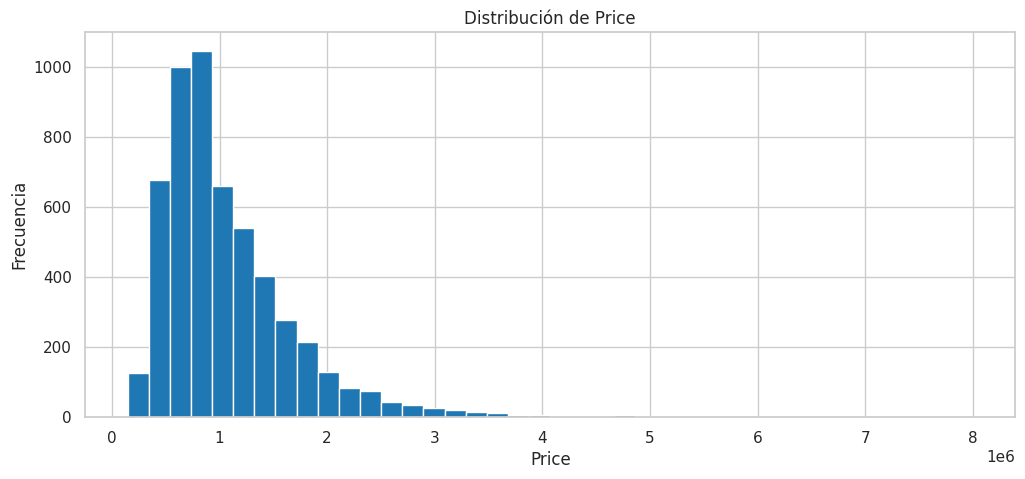

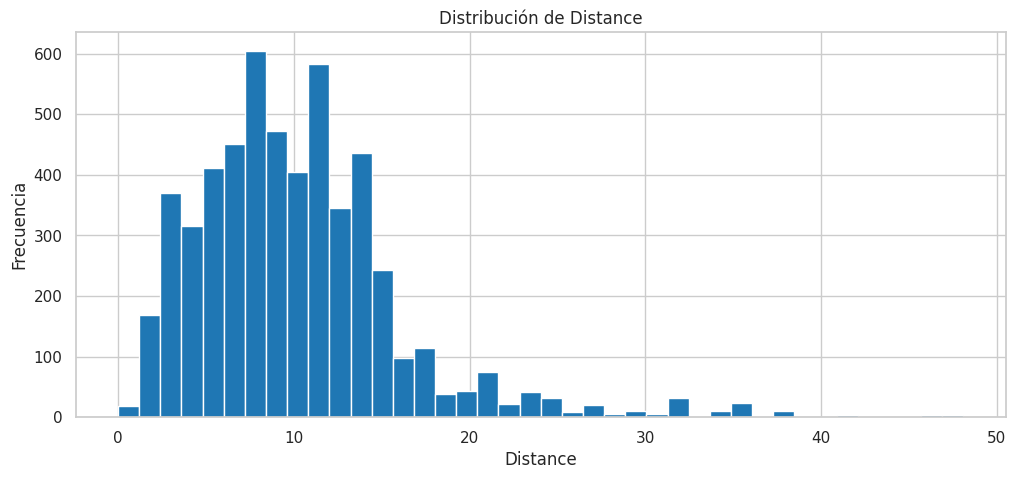

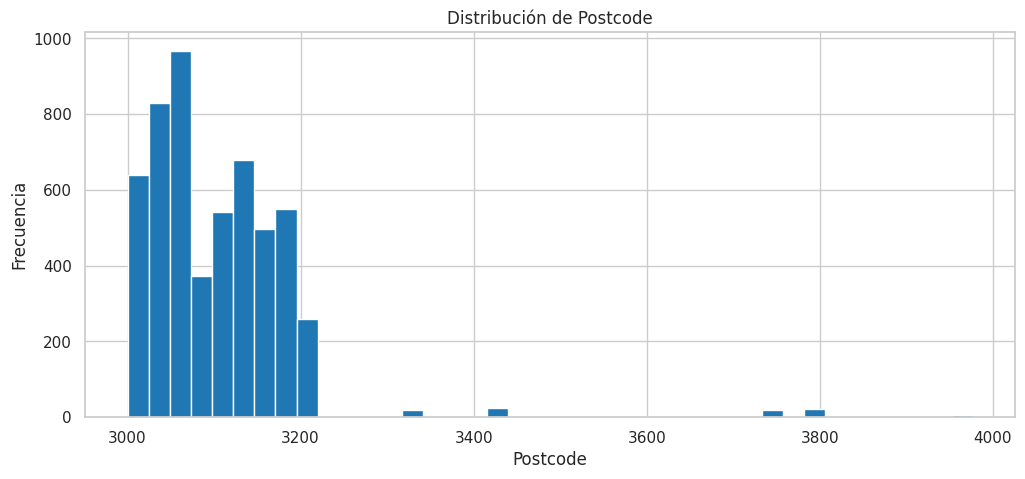

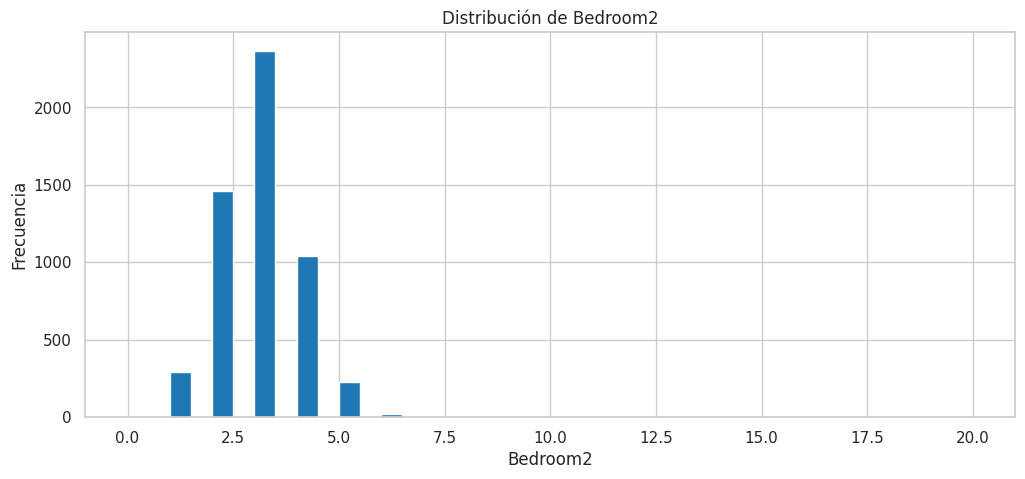

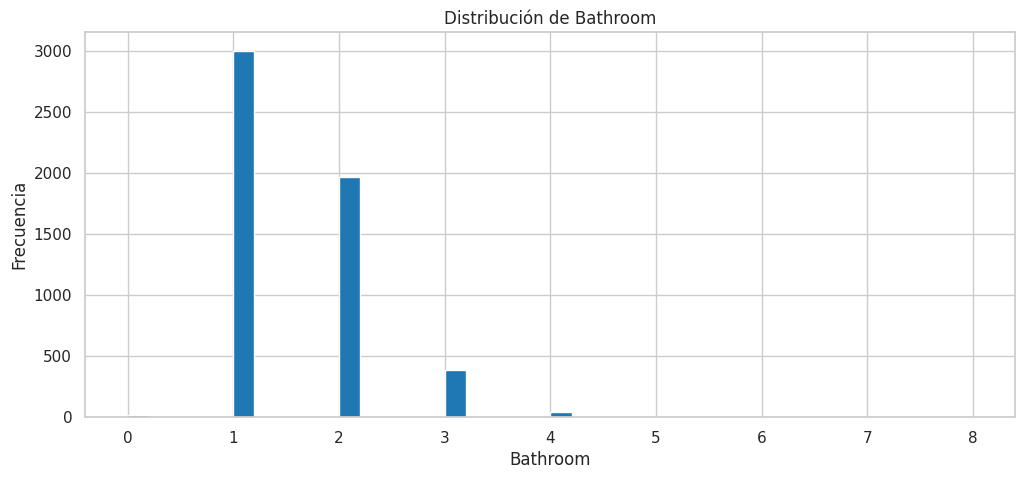

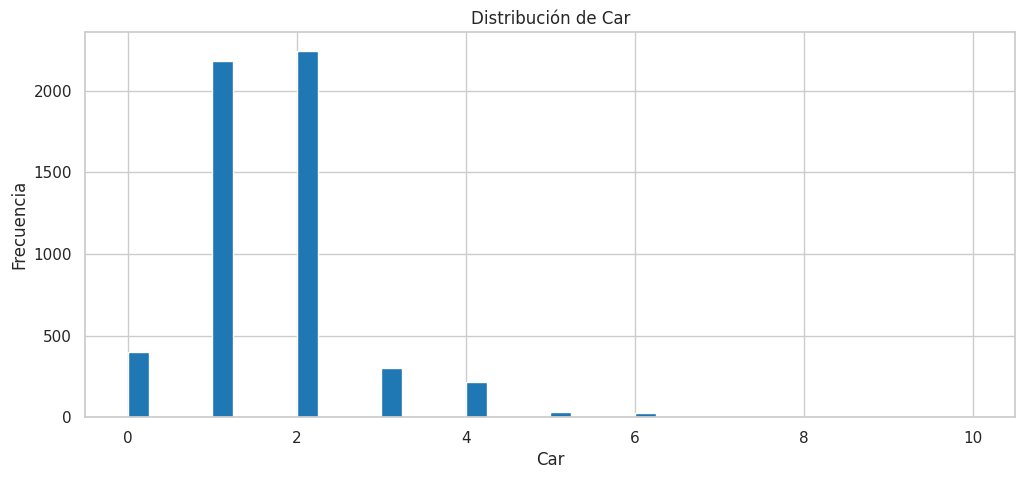

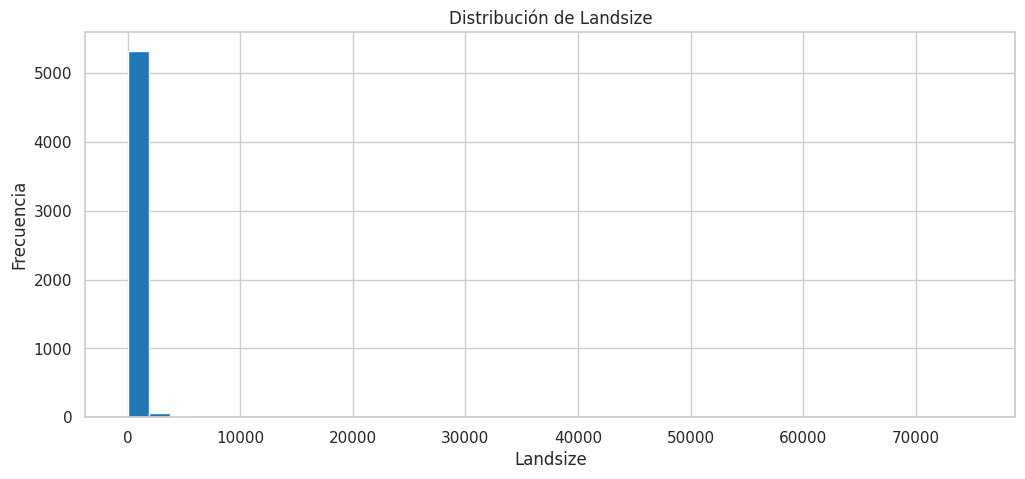

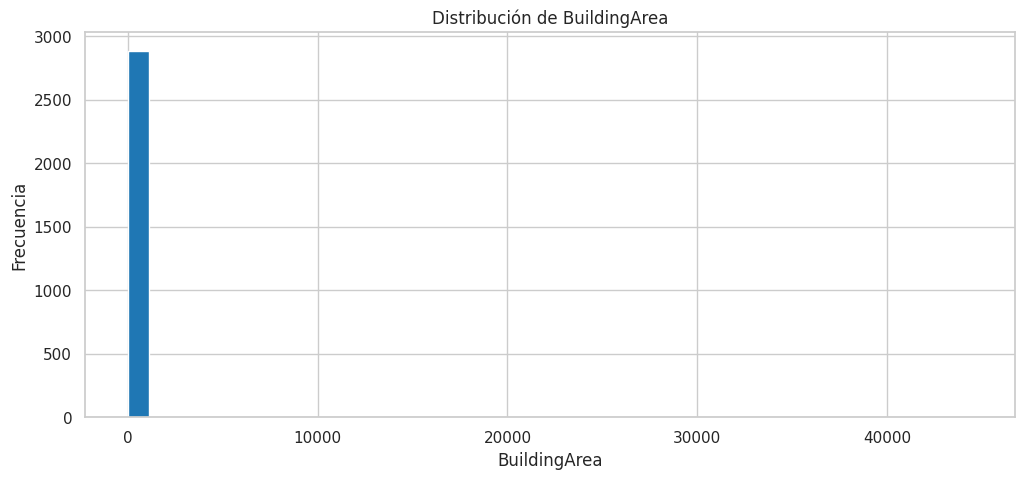

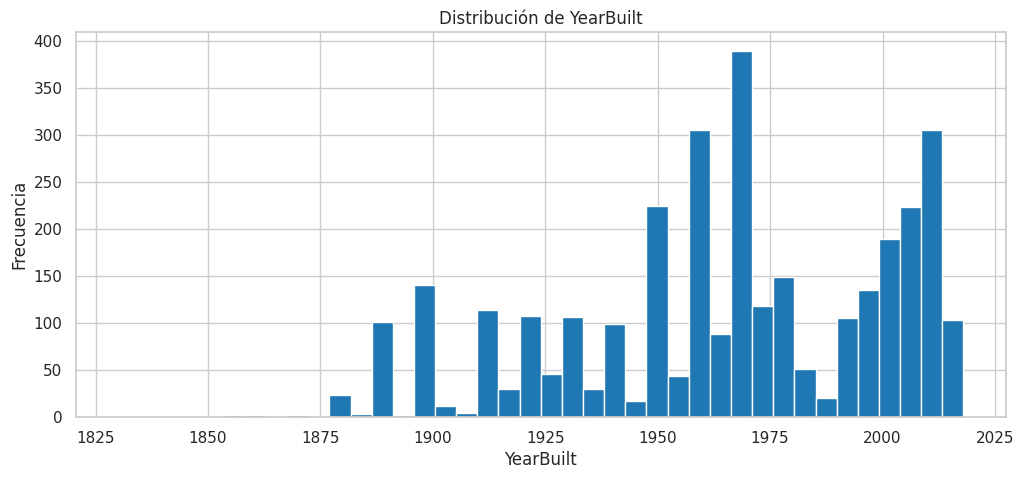

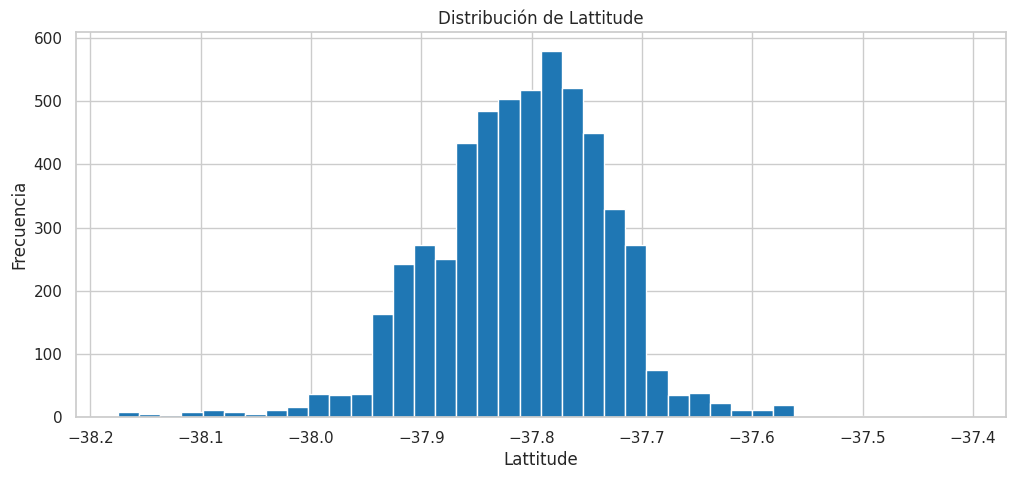

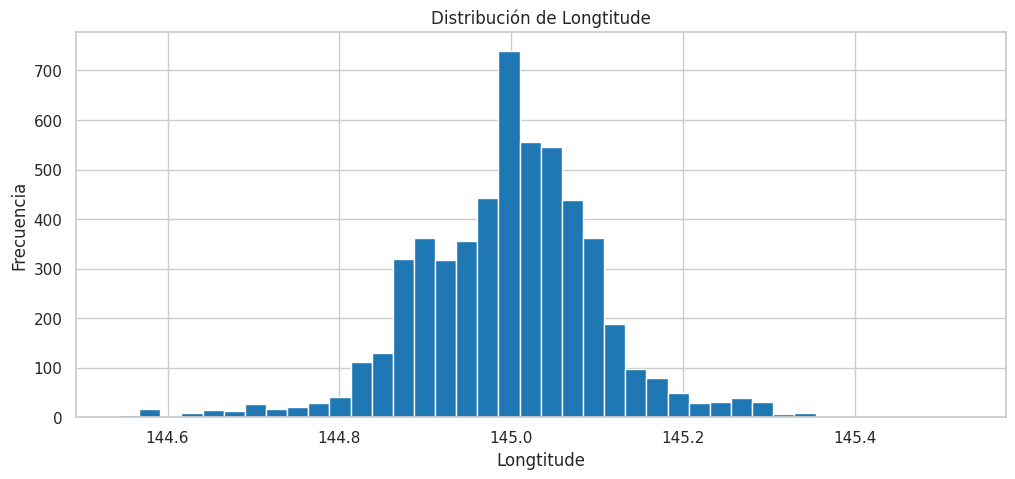

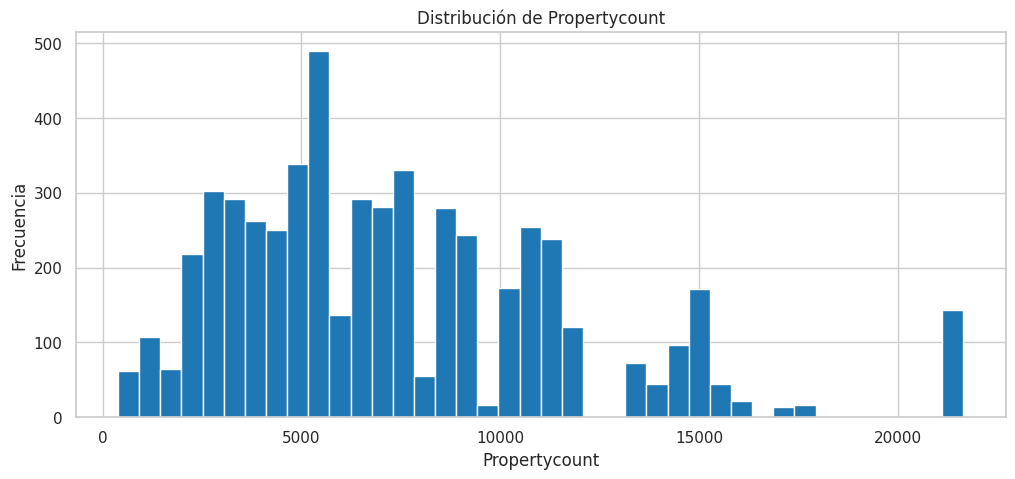


===== FIN DE RESUMEN =====


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_data(df):
    """
    Visualiza un DataFrame:
    - Número de filas y columnas
    - Columnas categóricas y sus frecuencias
    - Cuántas categorías tienen baja frecuencia (<20 y <10)
    - Columnas numéricas con rango y nulos
    - Matriz de correlación y distribuciones numéricas
    """

    print("===== INFORMACIÓN GENERAL =====")
    print(f"Número de columnas: {len(df.columns)}")
    print(f"Número de filas: {len(df)}\n")

    # --- Columnas categóricas ---
    print("=== Columnas de tipo object (strings/objetos) ===\n")
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    if len(cat_cols) == 0:
        print("No hay columnas categóricas.\n")
    else:
        for col in cat_cols:
            print(f"\nColumna: {col}")
            vc = df[col].value_counts(dropna=False)
            print(vc)
            under_20 = (vc < 20).sum()
            under_10 = (vc < 10).sum()
            print(f"--> Categorías con frecuencia <20: {under_20}")
            print(f"--> Categorías con frecuencia <10: {under_10}")
            print("-" * 60)

    # --- Columnas numéricas ---
    print("\n=== Columnas numéricas (int/float) ===\n")
    num_cols = df.select_dtypes(include=["number"]).columns
    for col in num_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"Columna: {col} | Min: {col_min:.2f} | Max: {col_max:.2f}")
        if df[col].isnull().sum() > 0:
            print(f"   -> Valores nulos: {df[col].isnull().sum()}")

    # --- Valores nulos ---
    print("\n=== Valores nulos por columna ===")
    print(df.isnull().sum())

    # --- Matriz de correlación ---
    print("\n=== Matriz de Correlación ===")
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Matriz de correlación")
        plt.show()
    else:
        print("No hay suficientes columnas numéricas para calcular correlación.\n")

    # --- Histogramas numéricos con nulos o rango amplio ---
    print("\n=== Histogramas de columnas numéricas ===")
    for col in num_cols:
            plt.figure()
            df[col].hist(bins=40)
            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.show()

    print("\n===== FIN DE RESUMEN =====")

visualize_data(train_set)


# Limpieza de datos

In [43]:
import pandas as pd

def one_hot_from_train(df_train, df_val, df_test, col, prefix, drop_first=True):
    """
    Crea dummies basándose SOLO en las categorías presentes en df_train.
    - Alinea df_val y df_test a esas columnas para evitar errores con columnas no existentes
    - Evita leakage: categorías nuevas en val/test NO crean columnas nuevas.

    Hacemos drop first true siempre para evitar multicolinealidad perfecta
    """
    #  categorías del TRAIN (orden estable)
    train_cats = pd.Categorical(df_train[col]).categories

    #  forzar mismo espacio categórico en los tres datasets
    for d in (df_train, df_val, df_test):
        d[col] = pd.Categorical(d[col], categories=train_cats)

    #  columnas "oficiales" de TRAIN
    train_dum = pd.get_dummies(df_train[col], prefix=prefix, drop_first=drop_first)  
    keep_cols = list(train_dum.columns)

    # aplicar y alinear a los 3 datasets
    for d in (df_train, df_val, df_test):
        
        dummies = pd.get_dummies(d[col], prefix=prefix, drop_first=drop_first)
        
        # limpiar cualquier dummy previa con ese prefijo
        d.drop(columns=[c for c in d.columns if c.startswith(prefix + "_")],
               inplace=True, errors="ignore")
        
        # reindex a las columnas del TRAIN
        d[keep_cols] = dummies.reindex(columns=keep_cols, fill_value=0)
        
        # quitar la columna original
        d.drop(columns=[col], inplace=True, errors="ignore")


In [63]:
def clean_data_test_and_train(df_train, df_val, df_test, umbral_base = 10):
    """
    En este método se va columna por columna tomando decisiones diferentes para limpiar los datos

    El umbral se usa para cuando hay pocos valores de un tipo agruparlos, para tener más estabilidad estadistica 
    """

    # ---- Suburb ----

    """
    En total hay 292 suburbios 

    Agrupamos los que tengan menos de 10 filas para que haya estabilidad en las estadísticas
    """

    # Tratar NaNs
    for d in (df_train, df_val, df_test):
        d['Suburb'] = d['Suburb'].astype('object').fillna('Suburb_missing')

    # Contar la frecuencia de cada región en train
    frecuencias = df_train['Suburb'].value_counts()
    
    # Definir el umbral para agrupar regiones poco frecuentes
    umbral = umbral_base
    
    # Cambiar las regiones que no superen el umbral por 'Otros suburbios
    df_train['Suburb'] = df_train['Suburb'].apply(lambda x: x if frecuencias.get(x,0) >= umbral else 'Suburb_other')     
    df_test['Suburb'] = df_test['Suburb'].apply(lambda x: x if frecuencias.get(x,0) >= umbral else 'Suburb_other')     
    df_val['Suburb'] = df_val['Suburb'].apply(lambda x: x if frecuencias.get(x,0) >= umbral else 'Suburb_other')     

    # Target encoding con train y la media del precio
    global_mean = df_train['Price'].mean()
    target_mean = df_train.groupby('Suburb')['Price'].mean()

    # Fallback: si no existe 'Suburb_other' en train, usa la media global ya que no existe la media en el train
    fallback = target_mean.get('Suburb_other', global_mean)

    # map + fallback para categorías no vistas o 'missing'
    df_train['Suburb_encoded'] = df_train['Suburb'].map(target_mean).fillna(fallback)
    df_val['Suburb_encoded']   = df_val['Suburb'].map(target_mean).fillna(fallback)
    df_test['Suburb_encoded']  = df_test['Suburb'].map(target_mean).fillna(fallback)
    



    # ------ ADDRESS ----------
    """
    No tiene sentido la columna en si, ya que cada casa tiene un address diferente

    Lo que podemos usar es su tipo de calle, que define el tipo de vivienda

    Agrupamos pocos frecuentes para estabilidad estadistica y hacemos one hot encoding para las 15 clases restantes
    """
    
    # separar en 3 columnas nuevas (el número y la calle dan igual, solo es útil el tipo)
    for d in (df_train, df_val, df_test):
        d['Address_Number'] = d['Address'].str.extract(r'(\d+)').astype(float)
        d['Address_Street'] = d['Address'].str.replace(r'\d+', '', regex=True).str.strip()
        d['Street_Type']    = d['Address_Street'].str.extract(r'(\b[A-Za-z]+)$')

    # Calcular categorías comunes con train 
    umbral_tipo_calle = umbral_base
    freq = df_train['Street_Type'].value_counts()
    comunes = freq[freq > umbral_tipo_calle].index

    # Juntar tipos poco frecuentes
    for d in (df_train, df_val, df_test):
        d['Street_Type'] = d['Street_Type'].apply(lambda x: x if x in comunes else 'Other')

    one_hot_from_train(df_train, df_val, df_test, col='Street_Type', prefix='Street', drop_first=True)



    # ----- TYPE -----
    """
    Hay solo 3 tipos, one hot encoding 
    """
    one_hot_from_train(df_train, df_val, df_test, col='Type', prefix='Type', drop_first=True)


    # ----- METHOD -------
    """
    Solo hay 5 metodos, one hot encoding
    """
    one_hot_from_train(df_train, df_val, df_test, col='Method', prefix='Method', drop_first=True)


    # ---- SellerG ----
    """
    Hay 200 tipos de seller, lo agrupamos para estabilidad estadistica y hacemos target encoding
    """
    
    umbral_seller = umbral_base

    # Agrupar inmobiliarias poco frecuentes de train
    freq = df_train['SellerG'].value_counts()
    comunes = freq[freq > umbral_seller].index

    for d in (df_train, df_val, df_test):
        d['SellerG'] = d['SellerG'].apply(lambda x: x if x in comunes else 'Seller_other')

    # Target encoding
    global_mean = df_train['Price'].mean()
    target_mean = df_train.groupby('SellerG')['Price'].mean()
    fallback = target_mean.get('Seller_other', global_mean)

    for d in (df_train, df_val, df_test):
        d['SellerG_encoded'] = d['SellerG'].map(target_mean).fillna(fallback)



    # --- Date ---
    """
    No sirve por si sola, creamos diferentes columnas a partir de esta 

    No creamos la columna de dia porque el dia del mes no afecta el precio
    Igual que la semana del año, no tiene un impacto directo una semana exacta

    La semana absoluta es variable temporal continua, ayuda a ver como va subiendo el precio
    """

    for d in (df_train, df_val, df_test):
        d['Date'] = pd.to_datetime(d['Date'], format='%d/%m/%Y', errors='coerce')
        d['Year'] = d['Date'].dt.year
        d['Month'] = d['Date'].dt.month
        d['Week_Absolute'] = (
            (d['Date'].dt.year - df_train['Date'].dt.year.min()) * 52    # mirar en que año esta respecto al minimo y sumar la semana
            + d['Date'].dt.isocalendar().week
        )

    # one hot para el mes y el año (no tiene sentido dejarlas como valor númerico porque diciembre(12) no vale más que enero (1))
    one_hot_from_train(df_train, df_val, df_test, col='Month', prefix='Month', drop_first=True)
    one_hot_from_train(df_train, df_val, df_test, col='Year',  prefix='Year',  drop_first=True)

    
    # ---- CouncilArea ----
    """
    Hay 33 council areas diferentes, volvemos a agrupar y a hacer target encoding
    """
    umbral = umbral_base

    # Rellenar NaNs
    for d in (df_train, df_val, df_test):
        d['CouncilArea'] = d['CouncilArea'].fillna('Unknown')

    # Calcular categorías comunes con train
    freq = df_train['CouncilArea'].value_counts()
    comunes = freq[freq > umbral].index

    # Agrupar categorías poco frecuentes 
    for d in (df_train, df_val, df_test):
        d['CouncilArea'] = d['CouncilArea'].apply(lambda x: x if x in comunes else 'Council_other')

    one_hot_from_train(df_train, df_val, df_test, col='CouncilArea', prefix='Council', drop_first=True)


    # ---- Regionname ----
    """
    Solo hay 8 regiones, no hace falta agrupar porque hay valores suficientes y al haber pocas clases hacemos OH
    """
        
    one_hot_from_train(df_train, df_val, df_test, col='Regionname', prefix='Region', drop_first=True)


    

    # -------- VARIABLES NUMÉRICAS ------

    # ----- Rooms and Bedrooms -----
    """
    Capamos outliers y aseguramos coherencia entre columnas 
    (no tiene sentido que haya más dormitorios que habitaciones)
    """
    
    for d in (df_train, df_val, df_test):
        
        # Capar Rooms a máximo 6
        d['Rooms'] = np.where(d['Rooms'] > 6, 6, d['Rooms'])

        # Forzar coherencia Bedroom2 ≤ Rooms
        d.loc[d['Bedroom2'] > d['Rooms'], 'Bedroom2'] = d['Rooms']

    
    # ------ Bathroom ------
    """
    Capar outliers y asegurar coherencia
    """
    
    for d in (df_train, df_val, df_test):
        # Ninguna vivienda habitable debería tener 0 baños
        d.loc[d['Bathroom'] == 0, 'Bathroom'] = 1
        # Capar valores extremos
        d['Bathroom'] = np.where(d['Bathroom'] > 4, 4, d['Bathroom'])
        # Forzar coherencia Bathroom ≤ Rooms
        d.loc[d['Bathroom'] > d['Rooms'], 'Bathroom'] = d['Rooms']

    # ------ Car ------
    """
    Gestionar los Nans que tiene y capar outliers
    """
    
    # Calcular media con train
    car_median = df_train['Car'].mean()

    for d in (df_train, df_val, df_test):

        # sustituir los nans por la media
        d['Car'] = d['Car'].fillna(car_median)
        d['Car'] = np.where(d['Car'] > 4, 4, d['Car'])


    # -------- Landsize --------
    """
    Hacer el logaritmo para evitar el sesgo de las viviendas con mucho terreno

    Hace más lineal la relación con el precio (duplicar el tamaño del terreno no multiplica el precio, pero sí lo aumenta de forma proporcional)
    """
    # Reemplazar 0 por NaN (no tiene sentido que no ocupe nada)
    for d in (df_train, df_val, df_test):
        d.loc[d['Landsize'] == 0, 'Landsize'] = np.nan

    # Calcular media y percentil 99 con train
    median_land = df_train['Landsize'].mean()
    upper_land = df_train['Landsize'].quantile(0.99)

    # Aplicar la media a los nans, aplicar logaritmo y capar outliers
    for d in (df_train, df_val, df_test):
        d['Landsize'] = d['Landsize'].fillna(median_land)
        d['Landsize'] = np.where(d['Landsize'] > upper_land, upper_land, d['Landsize'])
        d['Landsize_log'] = np.log1p(d['Landsize'])

    
    # -------- Building Area --------
    """
    Parecido a lo anterior. 
    Al ser building area podemos aproximar los valores NaN con el número de habitaciones ya que tiene una relación directa
    """
    
    # no tiene sentido un building area de 0
    for d in (df_train, df_val, df_test):
        d.loc[d['BuildingArea'] == 0, 'BuildingArea'] = np.nan

    # Calcular media y p99 de train
    mediana_global = df_train['BuildingArea'].mean()
    upper_build = df_train['BuildingArea'].quantile(0.99)

    # Coger la media de building area por rooms para valores nans 
    # (la cantidad de habitaciones es una aproximación del tamaño de la vivienda)
    mediana_por_rooms = df_train.groupby('Rooms')['BuildingArea'].mean()

    # Aplicar transformaciones en los tres conjuntos
    for d in (df_train, df_val, df_test):
        
        # Rellenar por media según nº de habitaciones si es NaN
        d['BuildingArea'] = d.apply(
            lambda row: mediana_por_rooms[row['Rooms']] 
                        if pd.isna(row['BuildingArea']) and row['Rooms'] in mediana_por_rooms 
                        else row['BuildingArea'],
            axis=1
        )
        
        # Si quedan NaN, usar media global
        d['BuildingArea'] = d['BuildingArea'].fillna(mediana_global)
        # Capar outliers
        d['BuildingArea'] = np.where(d['BuildingArea'] > upper_build, upper_build, d['BuildingArea'])
        # Transformación logarítmica
        d['BuildingArea_log'] = np.log1p(d['BuildingArea'])


    # ---------- Year Built ----------
    """
    Aqui marcamos en una columna nueva los edificios sin año de construcción .
    Normalmente cuando no se sabe el año es que es más antiguo y se ha perdido el dato (puede darnos contexto)

    Luego cambiamos el NaN por la media para usar ambas columnas y calculamos age que tiene relación más lineal con el precio
    """

    # flag con valores que faltan para mantener esta informacion
    for d in (df_train, df_val, df_test):
        d['YearBuilt_missing'] = d['YearBuilt'].isna().astype(int)

    # Calcular medias con train
    mediana_por_suburb = df_train.groupby('Suburb')['YearBuilt'].mean()
    mediana_global = df_train['YearBuilt'].mean()

    for d in (df_train, df_val, df_test):
        
         # mediana por suburbio para valores NaN, porque los barrios suelen tener viviendas construidas en épocas similares. 
        d['YearBuilt'] = d.apply(
            lambda row: mediana_por_suburb[row['Suburb']]
                        if pd.isna(row['YearBuilt']) and row['Suburb'] in mediana_por_suburb
                        else row['YearBuilt'],
            axis=1
        )
        # Rellenar lo que falte con mediana global
        d['YearBuilt'] = d['YearBuilt'].fillna(mediana_global)
        
        # un año 2000 no vale “dos veces más” que 1000. 
        # Lo que realmente influye en el precio es la antigüedad (cuánto tiempo ha pasado desde su construcción).
        d['Age'] = d['Date'].dt.year - d['YearBuilt']

    # ---------- Distance ----------
    """
    Aplicamos logaritmo ya que cada km del centro no es el doble de precio, sobretodo con valores más grandes
    """
    
    for d in (df_train, df_val, df_test):
        # Capar zonas muy lejanas
        d['Distance'] = np.where(d['Distance'] > 30, 30, d['Distance'])
        # Transformación logarítmica (mejor relación con Price)
        # La relación con el precio no suele ser lineal — cada kilómetro extra cerca del centro afecta más que los lejanos.
        d['Distance_log'] = np.log1p(d['Distance'])

    # ------- Latitude & Longitude --------------
    """
    Centramos los datos para tener datos más interpretables (no es lo mismo tener 39 o 39.5 que 0 y 0.5 )
    """
    
    # Calcular centro con train
    lat_mean = df_train['Lattitude'].mean()
    lon_mean = df_train['Longtitude'].mean()

    # calcular el punto central del dataset (Centra los datos estadísticamente para mejor estabilidad de datos)
    for d in (df_train, df_val, df_test):
        d['Lattitude_centered'] = d['Lattitude'] - lat_mean
        d['Longtitude_centered'] = d['Longtitude'] - lon_mean


    # --------- Postcode ------------
    """
    No tiene sentido como variable numerica, lo transformamos a categorica y hacemos target encoding agrupando
    codigos postales poco frecuentes. 
    """
    umbral_postcode = umbral_base

    # Frecuencias con train
    freq = df_train['Postcode'].value_counts()
    comunes = freq[freq > umbral_postcode].index

    # Agrupar códigos poco frecuentes en 'Other'
    for d in (df_train, df_val, df_test):
        d['Postcode'] = d['Postcode'].apply(lambda x: x if x in comunes else 'Other')

    # Target encoding con train
    global_mean = df_train['Price'].mean()
    postcode_price_mean = df_train.groupby('Postcode')['Price'].mean()
    fallback = postcode_price_mean.get('Other', global_mean)

    for d in (df_train, df_val, df_test):
        d['Postcode_encoded'] = d['Postcode'].map(postcode_price_mean).fillna(fallback)



    # ---------- Propertycount -------------
    """
    Capamos los outliers
    """

    
    # Calcular estadísticas cont train
    upper_prop = df_train['Propertycount'].quantile(0.99)

    for d in (df_train, df_val, df_test):
        # Capar outliers
        d['Propertycount'] = np.where(d['Propertycount'] > upper_prop, upper_prop, d['Propertycount'])




    # Limpieza acabada

    print("Limpieza acabada")
    print(f"Len de cada dataset {len(df_train)} {len(df_val)} {len(df_test)} ")
    
    return df_train, df_val, df_test

# Dividir el train en train y validation con `StratifiedShuffleSplit` y limpieza con el método anterior

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# DIVIDIR TRAIN CON ESTRATEGIA
# Hay pocos casos de casas muy caras (distribución sesgada) por eso estratificamos por bins de price
# asegura que train y validation mantengan proporciones similares en cada rango y la métrica sea representativa.

df_train_original = train_set.copy()
df_test_original  = test_set.copy()

# ----- bins de Price (mirar histograma para ver distribución) -----
bins   = [0.0, 500_000, 1_000_000, 1_500_000, 2_000_000, np.inf]
labels = [1, 2, 3, 4, 5]

# hacerlo en un df auxiliar para no tocar datos originales ni crear columnas innecesarias
df_aux = df_train_original.copy()
df_aux["price_cat"] = pd.cut(
    df_aux["Price"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# ----- split estratificado (80/20) solo sobre el TRAIN -----
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
(tr_idx, va_idx), = split.split(df_aux, df_aux["price_cat"])

# dividir en train y validation con el split
df_train_og = df_aux.iloc[tr_idx].drop(columns=["price_cat"]).copy()
df_val_og   = df_aux.iloc[va_idx].drop(columns=["price_cat"]).copy()

print("Train dividido en train y validation")
print("shapes -> train:", df_train_og.shape, "val:", df_val_og.shape, "test:", df_test_original.shape)

# LIMPIAR DATOS 
df_train, df_val, df_test = clean_data_test_and_train(df_train_og, df_val_og, df_test_original, umbral_base = 10)

Train dividido en train y validation
shapes -> train: (4345, 21) val: (1087, 21) test: (8148, 20)
Limpieza acabada
Len de cada dataset 4345 1087 8148 


# Estandarizar las varibables númericas 

Estandarizar pone todas las variables numéricas en la misma escala (media 0, desviación 1), evitando que una con valores grandes domine el ajuste solo por su magnitud.
Además mejora la estabilidad numérica y hace que los coeficientes sean comparables entre variables, logrando un modelo lineal más fiable y fácil de interpretar.

In [58]:
def scale_numeric_features(df_train, df_val, df_test, cols):
    """
    Estandariza columnas numéricas con media/std del TRAIN.
    Maneja std=0 dejando la columna centrada en 0.
    """
    for col in cols:
        mean_ = df_train[col].mean()
        std_  = df_train[col].std()
        if std_ == 0 or np.isclose(std_, 0):
            for d in (df_train, df_val, df_test):
                d[f"{col}_scaled"] = d[col] - mean_
        else:
            for d in (df_train, df_val, df_test):
                d[f"{col}_scaled"] = (d[col] - mean_) / std_

    print("Variables estandarizadas")
    return df_train, df_val, df_test

# Todas las columnas numericas a escalar
cols_a_escalar = [
    "Suburb_encoded","SellerG_encoded","Postcode_encoded",
    "Rooms","Bedroom2","Bathroom","Car","Landsize_log","BuildingArea_log",
    "Age","Distance_log","Lattitude_centered","Longtitude_centered",
    "Propertycount","Week_Absolute"
]
df_train, df_val, df_test = scale_numeric_features(df_train, df_val, df_test, cols_a_escalar)


Variables estandarizadas


/tmp/ipykernel_37/3849836851.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[f"{col}_scaled"] = (d[col] - mean_) / std_
/tmp/ipykernel_37/3849836851.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d[f"{col}_scaled"] = (d[col] - mean_) / std_
/tmp/ipykernel_37/3849836851.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fram

# Entrenar el modelo 

## Extraemos del df las nuevas columnas creadas para entrenar el modelo

In [59]:
def get_feature_columns(df_train):
    # prefijos de las columnas one hot encoding
    ohe_prefixes = ('Street_', 'Type_', 'Method_', 'Council_', 'Region_', 'Month_' , 'Year_')

    # columnas que no tienen patron
    keep_exact = ['YearBuilt_missing', 'Year', 'Month',]

    keep_exact = ['YearBuilt_missing']

    # numéricas escaladas
    scaled = [c for c in df_train.columns if c.endswith('_scaled')]

    # one-hot 
    dummies = [c for c in df_train.columns if c.startswith(ohe_prefixes)]

    # encodings y flags
    exact = [c for c in keep_exact if c in df_train.columns]

    # concatenar y deduplicar preservando orden
    seen = set()
    features = []
    for c in scaled + dummies + exact:
        if c not in seen:
            seen.add(c)
            features.append(c)

    return features

# úsalo así (siempre definido desde TRAIN para fijar el espacio de features):
FEATURE_COLS = get_feature_columns(df_train)
FEATURE_COLS = sorted(FEATURE_COLS)
print(f"{len(FEATURE_COLS)} features seleccionadas para entrenar el modelo")

print(FEATURE_COLS)


84 features seleccionadas para entrenar el modelo
['Age_scaled', 'Bathroom_scaled', 'Bedroom2_scaled', 'BuildingArea_log_scaled', 'Car_scaled', 'Council_Bayside', 'Council_Boroondara', 'Council_Brimbank', 'Council_Casey', 'Council_Council_other', 'Council_Darebin', 'Council_Frankston', 'Council_Glen Eira', 'Council_Greater Dandenong', 'Council_Hobsons Bay', 'Council_Hume', 'Council_Kingston', 'Council_Knox', 'Council_Manningham', 'Council_Maribyrnong', 'Council_Maroondah', 'Council_Melbourne', 'Council_Melton', 'Council_Monash', 'Council_Moonee Valley', 'Council_Moreland', 'Council_Nillumbik', 'Council_Port Phillip', 'Council_Stonnington', 'Council_Unknown', 'Council_Whitehorse', 'Council_Whittlesea', 'Council_Wyndham', 'Council_Yarra', 'Distance_log_scaled', 'Landsize_log_scaled', 'Lattitude_centered_scaled', 'Longtitude_centered_scaled', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB', 'Month_10', 'Month_11', 'Month_12', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month

# Greedy selection

Entrenar el modelo con cada feature y coger la que de mejor resultado. Repetir el proceso hasta que el modelo deje de aprender

Los parametros para elegir son
- Tipo de modelo (linear y knn)
- tolerancia a superar
- Agrupaciones de columnas (en vez de mirar 1 columna, mirar en grupos de n )

Además usaremos el target `Price` como logaritmo, por su distribución que tiene algunos precios muy elevados. 

Nosotros nos quedamos con el modelo lineal agrupando en grupos de 2. Hemos obtenido este resultado haciendo varias pruebas con diferentes parametros hasta obtener el mejor resultado. 

In [60]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from itertools import combinations

#  CONFIG 
FEATURES = FEATURE_COLS                # todas las features
target_col = "Price"                   # Columnas a predecir
model_type = "linear"                  # "linear" o "knn"
n_neighbors = 10                        # para knn
tol = 0.0                              # mejora mínima para que no desaprenda
group_size = 2                         # número de features a testear juntas

def make_model(model_type="linear", n_neighbors=3):
    if model_type == "linear":
        return LinearRegression()
    elif model_type == "knn":
        return KNeighborsRegressor(n_neighbors=n_neighbors)
    else:
        raise ValueError("No es ni linear ni knn")

def rmse_real(y_true_real, y_pred_real):
    return float(np.sqrt(mean_squared_error(y_true_real, y_pred_real)))

# coger las columnas que nos interesan del dataframe
Xtr_full = df_train[FEATURES]
Xva_full = df_val[FEATURES]

# transformamos el price en escala logaritmica para hacer más fácil el modelado.
ytr_log = np.log1p(df_train[target_col]).to_numpy().ravel()
yva_log = np.log1p(df_val[target_col]).to_numpy().ravel()

# valores en escala realreales para evaluar (invertimos log en cada pred)
yva_real = df_val[target_col].to_numpy().ravel()

# features que iremos eligiendo
selected = []
remaining = list(FEATURES)

# baseline: modelo sin features -> predecir media 
# un modelo base para tener un valor inicial de predicción
# full like crea un array como el de y_real con los valores de la media del precio en escala real
baseline_pred = np.full_like(yva_real, fill_value=np.expm1(ytr_log).mean())  # media en real
best_rmse = rmse_real(yva_real, baseline_pred)

k = 0
print(f"Baseline (sin features) - Val RMSE: {best_rmse:,.2f}")

while remaining:
    best_feat = None
    best_rmse_this_round = np.inf

    # generar todas las combinaciones posibles de tamaño group_size
    candidates = list(combinations(remaining, group_size))

    # por cada feature no usada (aun) junto a las ya usadas
    for feat_group in candidates:
        trial_feats = selected + list(feat_group)

        # extraer columnas seleccionadas
        Xtr = Xtr_full[trial_feats]
        Xva = Xva_full[trial_feats]

        # entrenar el modelo y ver la predicción hecha
        model = make_model(model_type, n_neighbors)
        model.fit(Xtr, ytr_log)
        yva_pred_log = model.predict(Xva)
        yva_pred_real = np.expm1(yva_pred_log)

        rmse_val = rmse_real(yva_real, yva_pred_real)

        # si es mejor guardamos
        if rmse_val < best_rmse_this_round:
            best_rmse_this_round = rmse_val
            best_feats = feat_group


    # si mejora respecto la última vez seguimos, si no paramos
    improvement = best_rmse - best_rmse_this_round
    if improvement > tol:
        selected.extend(best_feats)
        for f in best_feats:
            remaining.remove(f)
        best_rmse = best_rmse_this_round
        k += 1
        print(f"[{k}] Añadidas: {best_feats} | Val RMSE: {best_rmse:,.2f} | Mejora: {improvement:,.2f}")
    else:
        print(f"STOP --> no mejora (mejor RMSE val = {best_rmse:,.2f}, mejora={improvement:,.2f} <= tol={tol})")
        break




print("\n=== Resultado ===")
print(f"Features seleccionadas ({len(selected)}): {selected}")
print(f"Mejor Val RMSE: {best_rmse:,.2f}")

# Entrenar modelo con columnas seleccionadas
model_final = make_model(model_type, n_neighbors)
model_final.fit(Xtr_full[selected], ytr_log)

# Train
ytr_pred_real = np.expm1(model_final.predict(Xtr_full[selected]))
ytr_real = df_train[target_col].to_numpy().ravel()
rmse_train = rmse_real(ytr_real, ytr_pred_real)

# Val
yva_pred_real = np.expm1(model_final.predict(Xva_full[selected]))
ytr_real_val = df_val[target_col].to_numpy().ravel()
rmse_val = rmse_real(yva_real, yva_pred_real)
    
print(f"\nFinal -> Train RMSE: {rmse_train:,.2f} | Val RMSE: {rmse_val:,.2f}")


Baseline (sin features) - Val RMSE: 662,959.58
[1] Añadidas: ('Postcode_encoded_scaled', 'Rooms_scaled') | Val RMSE: 459,992.98 | Mejora: 202,966.59
[2] Añadidas: ('SellerG_encoded_scaled', 'Type_u') | Val RMSE: 415,754.75 | Mejora: 44,238.23
[3] Añadidas: ('Age_scaled', 'Bathroom_scaled') | Val RMSE: 389,979.39 | Mejora: 25,775.36
[4] Añadidas: ('Distance_log_scaled', 'Type_t') | Val RMSE: 374,402.44 | Mejora: 15,576.95
[5] Añadidas: ('BuildingArea_log_scaled', 'Region_Southern Metropolitan') | Val RMSE: 358,884.82 | Mejora: 15,517.62
[9] Añadidas: ('Council_Brimbank', 'Region_South-Eastern Metropolitan') | Val RMSE: 339,527.41 | Mejora: 2,649.31
[10] Añadidas: ('Council_Melton', 'Region_Eastern Victoria') | Val RMSE: 337,532.34 | Mejora: 1,995.07
[11] Añadidas: ('Month_12', 'Street_St') | Val RMSE: 336,172.39 | Mejora: 1,359.95
[12] Añadidas: ('Street_Gr', 'Street_Rd') | Val RMSE: 334,897.21 | Mejora: 1,275.18
[13] Añadidas: ('Council_Melbourne', 'Council_Stonnington') | Val RMSE: 33

# Valores predecidos vs valores reales en train y validation

----- EVALUATION ON TRAIN SET ------
RMSE: 333251.68927059433
R^2 : 0.7313584678142888


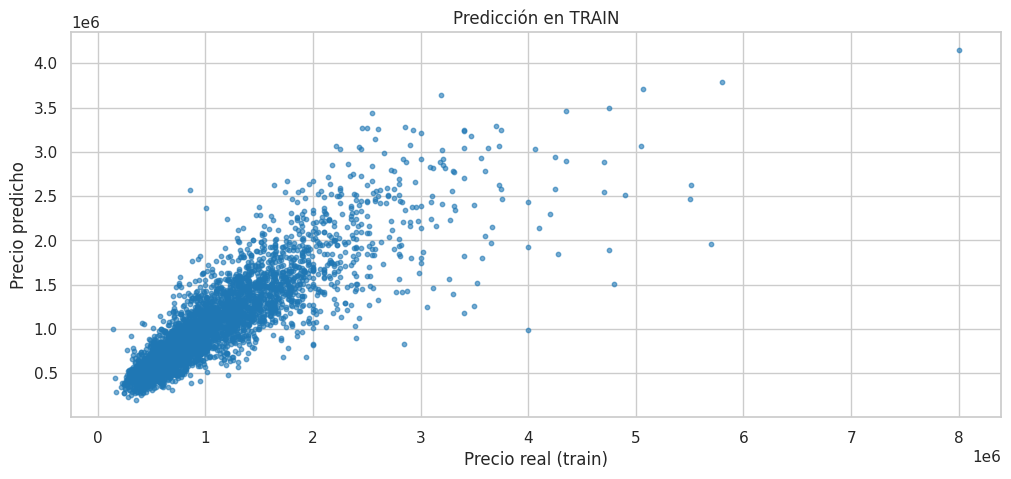

----- EVALUATION ON VALIDATION SET ------
RMSE: 329107.56222708884
R^2 : 0.7534225408139529


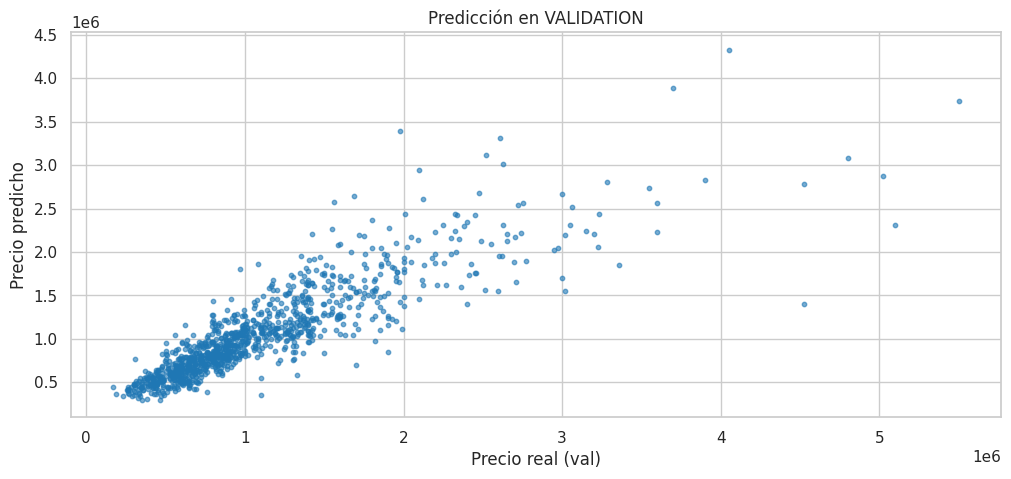

In [61]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("----- EVALUATION ON TRAIN SET ------")
print("RMSE:", rmse_train)
print("R^2 :", r2_score(ytr_real, ytr_pred_real))

plt.scatter(ytr_real, ytr_pred_real, s=10, alpha=0.6)
plt.xlabel('Precio real (train)')
plt.ylabel('Precio predicho')
plt.title('Predicción en TRAIN')
plt.grid(True)
plt.show()

print("----- EVALUATION ON VALIDATION SET ------")
print("RMSE:", rmse_val)
print("R^2 :", r2_score(yva_real, yva_pred_real))  

plt.scatter(yva_real, yva_pred_real, s=10, alpha=0.6)  
plt.xlabel('Precio real (val)')
plt.ylabel('Precio predicho')
plt.title('Predicción en VALIDATION')
plt.grid(True)
plt.show()


# Conclusion

el modelo lineal sobre log(Price) obtiene RMSE ≈ 333k en train y ≈ 329k en validación, con R² ≈ 0.73 y 0.75 respectivamente, lo que indica buen poder explicativo y generalización. Los Observed vs Predicted muestran ajuste sólido en el rango medio y mayor dispersión/subestimación en las viviendas de precio muy alto, problemas de usar un modelo lineal

# Creación de csv a partir de los datos del test para el submit

In [62]:
# asegura mismas columnas y orden que en el fit
X_test = df_test.reindex(columns=selected, fill_value=0)

# usa el modelo entrenado con las features seleccionadas
y_pred_log = model_final.predict(X_test)

# vuelve a escala real (deshacemos el log1p)
y_pred = np.expm1(y_pred_log).ravel()

# arma el dataframe de salida
df_output = pd.DataFrame({"Price": y_pred}).reset_index()
df_output.columns = ["index", "Price"]

print(f"Len del df creado {len(df_output)}")

df_output.to_csv("submission.csv", index=False)

Len del df creado 8148
